# Bean leaf disease classification

I built this notebook to train an image classifier that labels bean leaf photos as healthy, angular leaf spot, or bean rust. It connects to SDG 2 (Zero Hunger) and SDG 1 (No Poverty) in Rwanda: beans are a staple crop and a main protein source for smallholder farmers, so spotting disease early can protect a harvest and household income.

**Dataset:** [iBean](https://github.com/AI-Lab-Makerere/ibean) from Makerere AI Lab with Uganda's National Crops Resources Research Institute (NaCRRI). 1,296 field-collected leaf images across three balanced classes.

I go through loading the data, exploring it, preprocessing, training with MobileNetV2 transfer learning, evaluating on the test set, then a single-image prediction and a short retrain.


## Setup


In [1]:
!pip install -q datasets scikit-learn seaborn --upgrade
import sys
sys.path.append('../src')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize

from preprocessing import (
    IMG_SIZE, CLASS_NAMES, NUM_CLASSES,
    load_raw_datasets, export_split_to_disk,
    preprocess_image, build_pipeline,
)
from model import build_model, train_model, retrain_model
from prediction import predict_image, load_model

sns.set_style('whitegrid')
print('TF version:', tf.__version__)
print('Classes:', CLASS_NAMES)


TF version: 2.20.0
Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']


## 1. Data acquisition

I load the official iBean train, validation, and test splits from Hugging Face (`AI-Lab-Makerere/beans`) through `load_raw_datasets()` in `src/preprocessing.py`. I also export copies to `../data/train` and `../data/test` so the folders match the rest of the project and the API can use the same images when retraining.


In [3]:
train_raw, val_raw, test_raw = load_raw_datasets()

# These datasets are built from a generator, so cardinality is unknown
# ahead of time -- count directly instead.
n_train = sum(1 for _ in train_raw)
n_val = sum(1 for _ in val_raw)
n_test = sum(1 for _ in test_raw)
print('Train images:', n_train)
print('Val images:  ', n_val)
print('Test images: ', n_test)


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  144MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.5MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

Train images: 1034
Val images:   133
Test images:  128


In [4]:
# Write images into data/train and data/test
# Skip this cell if the folders are already filled
train_counts = export_split_to_disk(train_raw, 'train', out_dir='../data')
test_counts = export_split_to_disk(test_raw, 'test', out_dir='../data')
print('Train class counts:', train_counts)
print('Test class counts:', test_counts)


Train class counts: {'angular_leaf_spot': 345, 'bean_rust': 348, 'healthy': 341}
Test class counts: {'angular_leaf_spot': 43, 'bean_rust': 43, 'healthy': 42}


## 2. Data exploration

Before training I looked at three things:

1. Class counts, to see if the set is balanced
2. Sample images per class, to see how the diseases look different
3. Brightness per class, in case lighting alone could separate the labels


/tmp/ipykernel_3357/717760373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='YlGn')


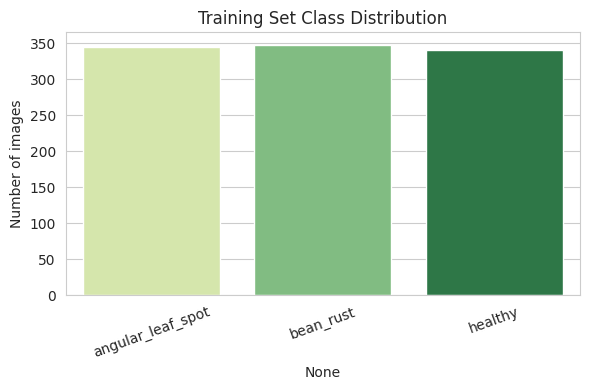

angular_leaf_spot    345
bean_rust            348
healthy              341
dtype: int64


In [5]:
# --- Feature 1: Class distribution ---
counts = pd.Series(train_counts)
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette='YlGn')
plt.title('Training Set Class Distribution')
plt.ylabel('Number of images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
print(counts)


The three classes are almost even (about 140 training images each before augmentation). That matters because a skewed set would push the model toward the majority class and make accuracy look fine while recall on the smaller classes stays weak. I did not need class weights or oversampling here.


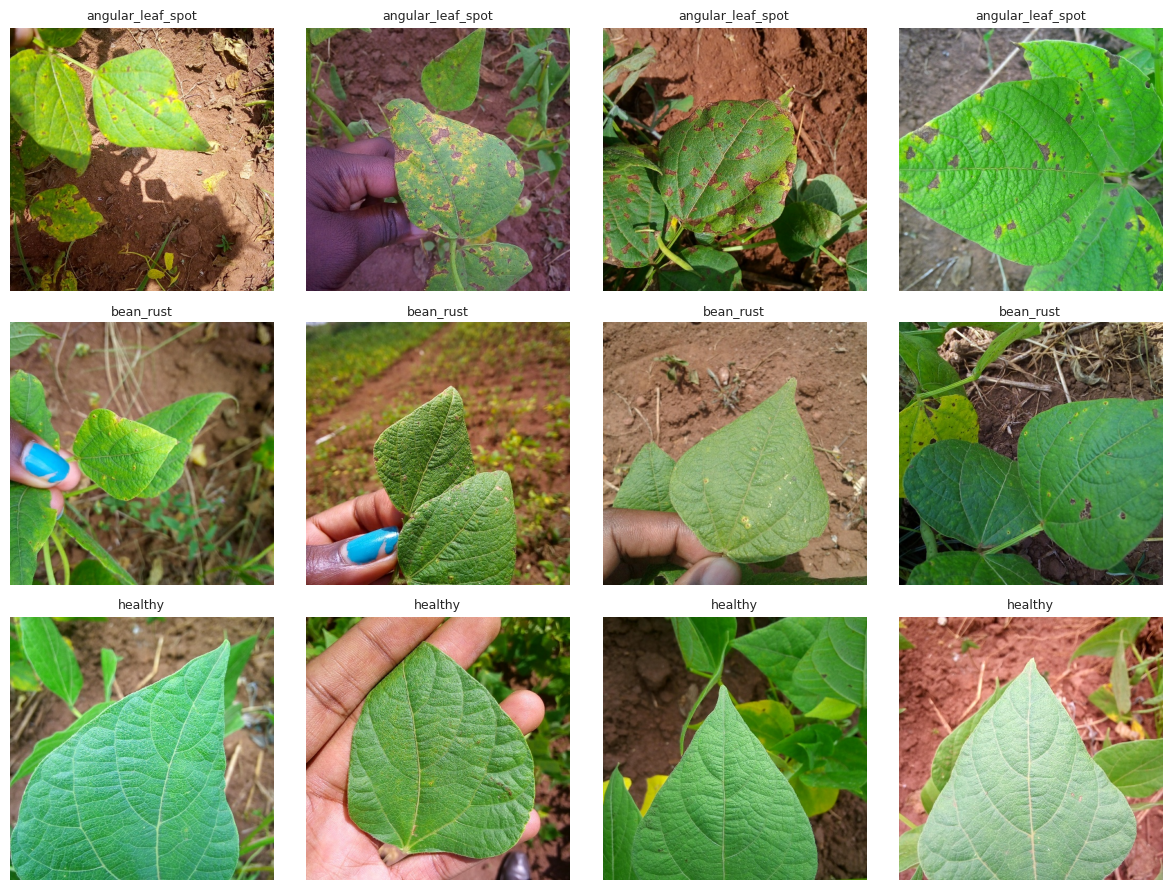

In [6]:
# --- Feature 2: Sample images per class ---
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for row, class_name in enumerate(CLASS_NAMES):
    shown = 0
    for image, label in train_raw.as_numpy_iterator():
        if CLASS_NAMES[label] == class_name and shown < 4:
            axes[row, shown].imshow(image)
            axes[row, shown].set_title(class_name, fontsize=9)
            axes[row, shown].axis('off')
            shown += 1
        if shown == 4:
            break
plt.tight_layout()
plt.show()


Angular leaf spot shows angular grey-brown lesions along the veins. Bean rust shows small reddish-brown circular pustules scattered on the leaf. Healthy leaves are evenly green. Those patterns are clear enough that a CNN should separate them without needing a very deep custom network.


/tmp/ipykernel_3357/3471075501.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bright_df, x='class', y='brightness', palette='YlOrBr')


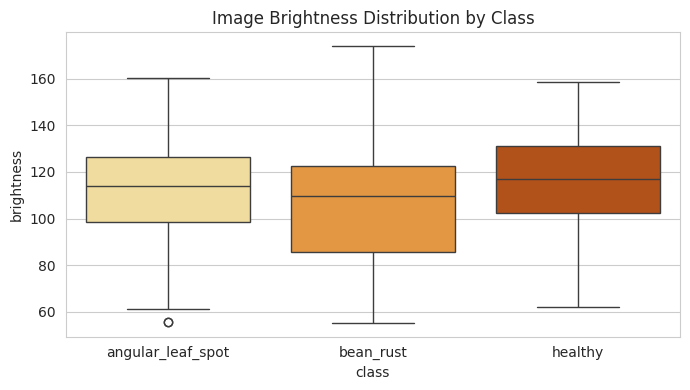

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
angular_leaf_spot,345.0,112.610742,19.918037,55.712199,98.454872,114.086325,126.261813,160.154333
bean_rust,348.0,106.137642,22.763350,55.379831,85.576192,109.851784,122.593997,173.896635
healthy,341.0,116.769710,18.988864,62.243868,102.351641,116.965339,131.077121,158.686296


In [7]:
# --- Feature 3: Brightness distribution per class ---
brightness_records = []
for image, label in train_raw.as_numpy_iterator():
    brightness = image.mean()
    brightness_records.append({'class': CLASS_NAMES[label], 'brightness': brightness})

bright_df = pd.DataFrame(brightness_records)
plt.figure(figsize=(7,4))
sns.boxplot(data=bright_df, x='class', y='brightness', palette='YlOrBr')
plt.title('Image Brightness Distribution by Class')
plt.tight_layout()
plt.show()

bright_df.groupby('class')['brightness'].describe()


Brightness ranges overlap a lot across classes, so lighting is not a shortcut the model can lean on instead of real disease features. That should help when new field photos are taken under different conditions than the original set.


## 3. Preprocessing

I use `preprocessing.build_pipeline` from `src/preprocessing.py` so training and the API share the same steps. That keeps train and serve from drifting apart.


In [8]:
BATCH_SIZE = 32

train_ds = build_pipeline(train_raw, batch_size=BATCH_SIZE, augment=True, shuffle=True)
val_ds   = build_pipeline(val_raw, batch_size=BATCH_SIZE, augment=False, shuffle=False)
test_ds  = build_pipeline(test_raw, batch_size=BATCH_SIZE, augment=False, shuffle=False)

# Sanity check a batch
for imgs, lbls in train_ds.take(1):
    print('Batch image shape:', imgs.shape)
    print('Batch label shape:', lbls.shape)
    print('Pixel range:', imgs.numpy().min(), '-', imgs.numpy().max())


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Pixel range: -0.17823207 - 1.2095705


## 4. Model

I use transfer learning on MobileNetV2 with a frozen base and a custom classification head. With about 1,300 images, training a CNN from scratch would probably overfit. Transfer learning keeps the pretrained visual features and I only need to learn the final classifier.


In [9]:
model = build_model(num_classes=NUM_CLASSES, fine_tune_base=False)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history, versioned_path, latest_path = train_model(
    model, train_ds, val_ds, epochs=15, model_dir='../models'
)
print('Saved versioned model to:', versioned_path)
print('Saved latest model to:  ', latest_path)


Epoch 1/15
     33/Unknown 37s 420ms/step - accuracy: 0.5565 - loss: 0.9453

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


33/33 ━━━━━━━━━━━━━━━━━━━━ 53s 930ms/step - accuracy: 0.6721 - loss: 0.7243 - val_accuracy: 0.8421 - val_loss: 0.4414
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7966 - loss: 0.4727

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8143 - loss: 0.4387 - val_accuracy: 0.8797 - val_loss: 0.2930
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8656 - loss: 0.3224 - val_accuracy: 0.8797 - val_loss: 0.2484
Epoch 4/15
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8592 - loss: 0.3472

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8956 - loss: 0.2860 - val_accuracy: 0.9098 - val_loss: 0.2354
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8868 - loss: 0.2842 - val_accuracy: 0.9023 - val_loss: 0.2483
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8936 - loss: 0.2554 - val_accuracy: 0.9098 - val_loss: 0.2349
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9130 - loss: 0.2442 - val_accuracy: 0.8947 - val_loss: 0.2712
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9105 - loss: 0.2170

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9052 - loss: 0.2309 - val_accuracy: 0.9248 - val_loss: 0.2238
Epoch 9/15
31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9181 - loss: 0.2264

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9130 - loss: 0.2173 - val_accuracy: 0.9323 - val_loss: 0.2039
Epoch 10/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9062 - loss: 0.2264 - val_accuracy: 0.9098 - val_loss: 0.2230
Epoch 11/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9178 - loss: 0.2200 - val_accuracy: 0.8797 - val_loss: 0.2601
Epoch 12/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9149 - loss: 0.2190 - val_accuracy: 0.9248 - val_loss: 0.2071
Epoch 13/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - accuracy: 0.9197 - loss: 0.2004 - val_accuracy: 0.8947 - val_loss: 0.2649


Saved versioned model to: ../models/bean_model_20260722_224439.h5
Saved latest model to:   ../models/bean_model_latest.h5


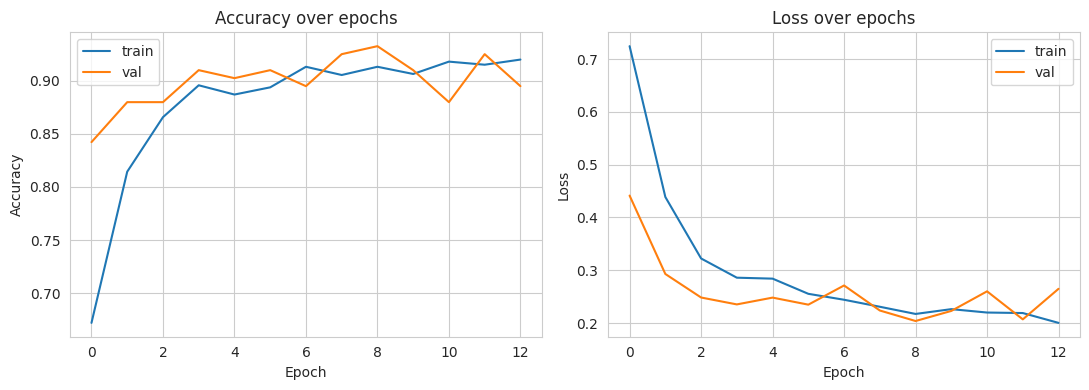

In [11]:
plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss over epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()


## 5. Evaluation

I evaluate on the held-out test set with accuracy, precision, recall, F1 (per class and macro-averaged), a confusion matrix, and one-vs-rest ROC-AUC for the three classes.


In [12]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_probs = model.predict(test_ds)
y_pred = np.argmax(y_probs, axis=1)

print('Overall Accuracy:', accuracy_score(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step
Overall Accuracy: 0.8984375

                   precision    recall  f1-score   support

angular_leaf_spot     0.7963    1.0000    0.8866        43
        bean_rust     0.9697    0.7442    0.8421        43
          healthy     0.9756    0.9524    0.9639        42

         accuracy                         0.8984       128
        macro avg     0.9139    0.8989    0.8975       128
     weighted avg     0.9134    0.8984    0.8970       128



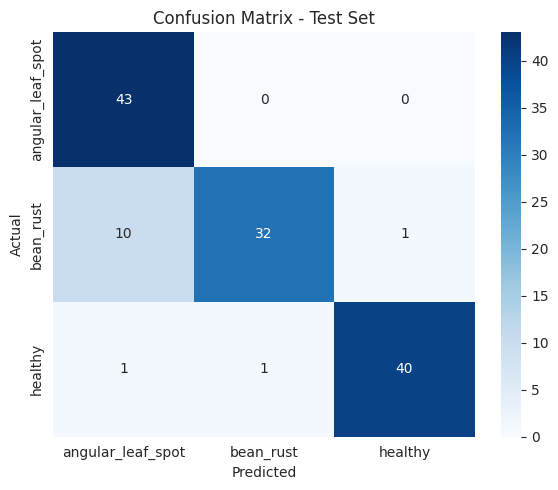

In [13]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()


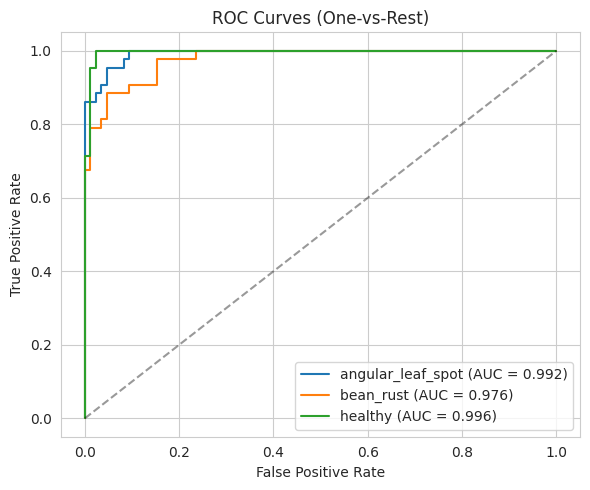

In [14]:
# ROC-AUC (one-vs-rest) per class
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(6,5))
for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
summary_metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'precision_macro': precision_score(y_true, y_pred, average='macro'),
    'recall_macro': recall_score(y_true, y_pred, average='macro'),
    'f1_macro': f1_score(y_true, y_pred, average='macro'),
}
pd.DataFrame([summary_metrics])


,accuracy,precision_macro,recall_macro,f1_macro
0,0.898438,0.913868,0.898856,0.89752


From the classification report and confusion matrix above, most of what I care about is where the errors land. Angular leaf spot and bean rust can look alike, so I expect confusion between those two more than with healthy leaves.


## 6. Single image prediction

This is the same path the API `/predict` endpoint uses: one image in, class and confidence out.


In [16]:
# Take one test image and run prediction on it
for image, label in test_raw.take(1).as_numpy_iterator():
    tf.keras.utils.save_img('../data/test/_demo_sample.jpg', image)
    true_label = CLASS_NAMES[label]

result = predict_image(image_path='../data/test/_demo_sample.jpg', model_path=latest_path)
print('True label:', true_label)
print('Prediction:', result)


True label: angular_leaf_spot
Prediction: {'predicted_class': 'angular_leaf_spot', 'confidence': 0.9938729405403137, 'class_probabilities': {'angular_leaf_spot': 0.9938729405403137, 'bean_rust': 0.006095543969422579, 'healthy': 3.1473849958274513e-05}}


## 7. Retraining

This walks through what happens after new images land in `data/train` and the API `/retrain` endpoint runs. The next cell uses the validation split as stand-in new data so I can call the retrain function without waiting on real uploads.


In [17]:
# In the API, new images would come from uploads.
# Here the validation split stands in for new data
# so I can show the retrain call.
new_train_ds = build_pipeline(val_raw, batch_size=BATCH_SIZE, augment=True, shuffle=True)
new_val_ds = build_pipeline(val_raw, batch_size=BATCH_SIZE, augment=False, shuffle=False)

retrain_history, new_versioned_path, new_latest_path = retrain_model(
    new_train_ds, new_val_ds, model_dir='../models', epochs=3
)
print('Retrained model saved to:', new_versioned_path)


Epoch 1/3
      5/Unknown 15s 1s/step - accuracy: 0.8935 - loss: 0.2621  

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8947 - loss: 0.2596 - val_accuracy: 0.9248 - val_loss: 0.2023
Epoch 2/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8872 - loss: 0.2375 - val_accuracy: 0.9173 - val_loss: 0.2036
Epoch 3/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8872 - loss: 0.2754 - val_accuracy: 0.9173 - val_loss: 0.2036


Retrained model saved to: ../models/bean_model_20260722_224636.h5


## Summary

Section 5 has the test-set metrics. The model, preprocessing, and prediction code live in `src/`, and the FastAPI app in `api/` imports them directly, so training and production share the same path. The API exposes `/predict`, `/upload-data`, `/retrain`, and `/status`.
